# Data Preparation: Patient-Grouped Split & Controlled Preprocessing

**EEEM068 Applied Machine Learning — University of Surrey**
**Dataset:** Kaggle Diabetic Retinopathy Detection (**labelled training data only**)

---

## Purpose

This notebook turns the raw, archived Kaggle Diabetic Retinopathy dataset into a small set of
clean, reproducible artefacts that every later notebook (training, evaluation) can rely on
without re-deriving anything:

- a **patient-grouped** train / validation / internal-test split, with zero patient leakage
  between partitions, saved as plain CSV manifests (no images are ever moved or copied);
- two **deterministic** preprocessing functions (a conservative baseline and a Ben Graham
  variant) sharing identical crop/pad logic, so they differ by exactly one operation;
- **training-only** class statistics and three families of class weights for later
  loss-function experiments.

Everything here is designed to fail loudly rather than silently: missing files, malformed
labels, parsing failures, and partition imbalance are all checked with explicit assertions
instead of being quietly dropped or ignored.

## Data used

| Input | Used? |
|---|---|
| `train.zip.001` – `train.zip.005` | Yes — extracted by this notebook |
| `trainLabels.csv.zip` | Yes — extracted by this notebook |
| `test.zip.001` – `test.zip.007` | **No** — never extracted or referenced |
| `sampleSubmission.csv.zip`, `sample.zip` | **No** — never extracted or referenced |

The official Kaggle test archives have no ground-truth labels and are irrelevant to a
supervised train/validation/internal-test split, so this notebook does not touch them at all.

## Notebook section structure

1. Imports and reproducibility
2. Paths and configuration
3. Archive extraction (labelled data only)
4. Load labels and validate image files (strict)
5. Extract and validate patient ID and eye laterality
6. Dataset and class-imbalance analysis
7. Patient-grouped train / validation / internal-test split
8. Split-integrity, leakage and class-coverage checks
9. Save split manifests and split metadata
10. Basic preprocessing function (P0)
11. Ben Graham preprocessing function (P1)
12. Preprocessing visual comparison
13. Training-only class-weight calculations
14. Save class statistics and figures
15. Final data-preparation summary

## How to run this notebook

Run **Restart Kernel & Run All** from top to bottom. The notebook is idempotent by design:

- If `trainLabels.csv` and all 35,126 training images are already extracted, Section 3 simply
  reports this and skips extraction — nothing is re-downloaded or re-extracted.
- Running the notebook a second time should produce byte-identical CSV manifests, JSON
  statistics, and figures, because every random step is seeded from a single `RANDOM_SEED`.

A clean run is expected to finish by printing, among other things:

```
Total labelled images: 35,126
Training-split images: 24,586
Missing labelled files   : 0
Patient overlap          : 0 / 0 / 0
All five classes present in every partition: True
```


## 1. Imports and reproducibility

Includes the standard scientific-Python stack plus `zipfile`, `shutil` and `subprocess`,
which are needed for archive extraction in Section 3. A single `RANDOM_SEED` controls every
source of randomness in this notebook (the split search in Section 7 and the sampling used
for visual examples), so the whole pipeline is reproducible end-to-end.


In [1]:

import json
import random
import shutil
import subprocess
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageStat

import cv2
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'RANDOM_SEED = {RANDOM_SEED}')
print(f'numpy      : {np.__version__}')
print(f'pandas     : {pd.__version__}')
print(f'opencv     : {cv2.__version__}')


RANDOM_SEED = 42
numpy      : 1.26.4
pandas     : 2.3.2
opencv     : 4.6.0


## 2. Paths and configuration

Paths are set explicitly for this environment's directory layout:

```
/scratch/New AML/
├── EEEM068-LSA-Diabetic-Retinopathy      <- PROJECT_ROOT (this repo / notebook)
└── diabetic-retinopathy-detection        <- DATA_ROOT (raw Kaggle archives + extracted data)
```

`DATA_ROOT` is a **sibling** of `PROJECT_ROOT`, not a subfolder of it — hence
`PROJECT_ROOT.parent / "diabetic-retinopathy-detection"` rather than
`PROJECT_ROOT / "data" / ...`.

All notebook outputs (split manifests, statistics, tables, figures) are written under
`PROJECT_ROOT`, keeping generated artefacts separate from the (large, archive-based) raw data
directory.


In [2]:

# Project and data roots
PROJECT_ROOT = Path("/scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy")
DATA_ROOT    = PROJECT_ROOT.parent / "diabetic-retinopathy-detection"

# Raw inputs: images directory, labels CSV, and the two archives we extract
TRAIN_DIR      = DATA_ROOT / "train"
LABELS_CSV     = DATA_ROOT / "trainLabels.csv"
TRAIN_ARCHIVE  = DATA_ROOT / "train.zip.001"       # 7z auto-follows .002 .. .005
LABELS_ARCHIVE = DATA_ROOT / "trainLabels.csv.zip"

# Notebook outputs
CONFIG_DIR  = PROJECT_ROOT / "configs"
SPLITS_DIR  = CONFIG_DIR / "splits"
TABLES_DIR  = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures" / "data_preparation"

for directory in [CONFIG_DIR, SPLITS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CLASS_NAMES  = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative DR'}
CLASS_COLORS = ['#2ECC71', '#F39C12', '#E67E22', '#E74C3C', '#8E44AD']
NUM_CLASSES  = 5

# Split configuration
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

EXPECTED_IMAGE_COUNT = 35_126

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'DATA_ROOT    : {DATA_ROOT}')
print()
print('Output locations:')
for label, p in [('configs', CONFIG_DIR), ('configs/splits', SPLITS_DIR),
                  ('results/tables', TABLES_DIR), ('results/figures', FIGURES_DIR)]:
    print(f'  {label:<16}: {p}')


PROJECT_ROOT : /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy
DATA_ROOT    : /scratch/New AML/diabetic-retinopathy-detection

Output locations:
  configs         : /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/configs
  configs/splits  : /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/configs/splits
  results/tables  : /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/tables
  results/figures : /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/data_preparation


## 3. Archive extraction (labelled data only)

This section extracts **only** the two labelled-data archives:

- `trainLabels.csv.zip` -> `trainLabels.csv`
- `train.zip.001` ... `train.zip.005` -> `train/*.jpeg` (35,126 images; 7-Zip follows the
  remaining parts automatically once given the first)

It **never** extracts, downloads, or otherwise touches:

- `test.zip.001` – `test.zip.007` (the official, unlabelled Kaggle test set)
- `sampleSubmission.csv.zip`
- `sample.zip`

Both extraction steps are **idempotent**:

- If `trainLabels.csv` already exists, the label extraction step is skipped entirely.
- If exactly `EXPECTED_IMAGE_COUNT` (35,126) `.jpeg` files are already present in `train/`,
  the image extraction step is skipped. If a *different, non-zero* number of images is found,
  the notebook raises an error rather than silently continuing with a partial extraction —
  a partial extraction is worse than no extraction, because it can look like a complete,
  valid dataset while quietly missing images.


In [3]:

# Extract trainLabels.csv
if LABELS_CSV.exists():
    print('trainLabels.csv is already extracted.')
else:
    if not LABELS_ARCHIVE.exists():
        raise FileNotFoundError(f'Labels archive not found: {LABELS_ARCHIVE}')

    with zipfile.ZipFile(LABELS_ARCHIVE, 'r') as archive:
        archive.extractall(DATA_ROOT)

    if not LABELS_CSV.exists():
        raise RuntimeError('Archive was extracted, but trainLabels.csv was not found.')

    print('Successfully extracted trainLabels.csv.')


trainLabels.csv is already extracted.


In [4]:

# Extract train.zip.001-005 (multi-part 7-Zip archive)
existing_images = list(TRAIN_DIR.glob('*.jpeg')) if TRAIN_DIR.exists() else []

if len(existing_images) == EXPECTED_IMAGE_COUNT:
    print(f'Training images already extracted: {len(existing_images):,}')

else:
    if existing_images:
        raise RuntimeError(
            f'Partial extraction detected. Found {len(existing_images):,} images '
            f'instead of {EXPECTED_IMAGE_COUNT:,}. Resolve this manually before continuing '
            f'(e.g. delete train/ and re-run this cell) rather than proceeding with an '
            f'incomplete dataset.'
        )

    if not TRAIN_ARCHIVE.exists():
        raise FileNotFoundError(f'Training archive not found: {TRAIN_ARCHIVE}')

    if shutil.which('7z') is None:
        raise RuntimeError('7z is unavailable. The multipart archive cannot be extracted '
                            'from this notebook.')

    TRAIN_DIR.mkdir(parents=True, exist_ok=True)

    subprocess.run(['7z', 'x', str(TRAIN_ARCHIVE), f'-o{TRAIN_DIR}', '-y'], check=True)

    # Some archive layouts create a nested train/train/*.jpeg -- flatten if present
    nested_train = TRAIN_DIR / 'train'
    if nested_train.exists():
        for image_path in nested_train.glob('*.jpeg'):
            shutil.move(str(image_path), str(TRAIN_DIR / image_path.name))
        nested_train.rmdir()

    extracted_images = list(TRAIN_DIR.glob('*.jpeg'))
    if len(extracted_images) != EXPECTED_IMAGE_COUNT:
        raise RuntimeError(
            f'Expected {EXPECTED_IMAGE_COUNT:,} images, but found {len(extracted_images):,}.'
        )

    print(f'Successfully extracted {len(extracted_images):,} training images.')

print()
print('Not extracted (by design, official Kaggle test / submission archives):')
for name in ['test.zip.001-007', 'sampleSubmission.csv.zip', 'sample.zip']:
    print(f'  - {name}')


Training images already extracted: 35,126

Not extracted (by design, official Kaggle test / submission archives):
  - test.zip.001-007
  - sampleSubmission.csv.zip
  - sample.zip


## 4. Load labels and validate image files (strict)

This section loads `trainLabels.csv` and validates it strictly: **any** structural problem
(missing columns, missing values, duplicate image names, out-of-range labels, or missing
image files) raises an exception rather than being fixed up or dropped silently.

Silently filtering out rows whose file is missing would hide a broken or incomplete
extraction behind a smaller-but-plausible-looking dataset. If the checks in this section
pass, we know the full labelled dataset is present and internally consistent.


In [5]:

df = pd.read_csv(LABELS_CSV)

# Check the expected number of label rows.
if len(df) != EXPECTED_IMAGE_COUNT:
    raise ValueError(
        f'Expected {EXPECTED_IMAGE_COUNT:,} label rows, '
        f'but found {len(df):,}.'
    )

# Check that the required columns exist.
required_columns = {'image', 'level'}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f'Missing CSV columns: {sorted(missing_columns)}'
    )

# Check for missing values.
if df.isna().any().any():
    raise ValueError(
        'Missing values found in trainLabels.csv.'
    )

# Check for duplicate image names.
if df['image'].duplicated().any():
    raise ValueError(
        'Duplicate image names found.'
    )

# Check that labels are stored as integers.
if not pd.api.types.is_integer_dtype(df['level']):
    raise TypeError(
        'The level column must contain integer labels.'
    )

# Check that all labels are within the valid range 0-4.
if not df['level'].isin(range(NUM_CLASSES)).all():
    raise ValueError(
        'Labels outside the valid range 0-4 found.'
    )

# Construct the full path for each labelled image.
df['filepath'] = df['image'].apply(
    lambda name: str(TRAIN_DIR / f'{name}.jpeg')
)

# Check that every labelled image exists.
missing_files = df.loc[
    ~df['filepath'].map(lambda path: Path(path).exists()),
    'image'
]

if len(missing_files) > 0:
    raise FileNotFoundError(
        f'{len(missing_files):,} labelled images are missing. '
        f'Examples: {missing_files.head().tolist()}'
    )

# Display validation summary.
print(f'trainLabels.csv rows       : {len(df):,}')
print(f'Validated labelled images  : {len(df):,}')
print(f'Missing labelled files     : {len(missing_files):,}')
print(
    f'Grade range                : '
    f'{df["level"].min()} - {df["level"].max()}'
)

df.head(6)

trainLabels.csv rows       : 35,126
Validated labelled images  : 35,126
Missing labelled files     : 0
Grade range                : 0 - 4


,image,level,filepath
0,10_left,0,/scratch/New AML/diabetic-retinopathy-detectio...
1,10_right,0,/scratch/New AML/diabetic-retinopathy-detectio...
2,13_left,0,/scratch/New AML/diabetic-retinopathy-detectio...
3,13_right,0,/scratch/New AML/diabetic-retinopathy-detectio...
4,15_left,1,/scratch/New AML/diabetic-retinopathy-detectio...
5,15_right,2,/scratch/New AML/diabetic-retinopathy-detectio...


## 5. Extract and validate patient ID and eye laterality

Image names follow the pattern `{patient_id}_{left|right}`, e.g. `1_left`. Both fields are
parsed with regular expressions and then explicitly checked for parsing failures — an
unparseable `patient_id` or `eye` would otherwise silently become `NaN` and could corrupt the
patient-grouped split in Section 7 without any visible error.

Required columns from this point on: `image`, `level`, `patient_id`, `eye`, `filepath`.


In [6]:

df['patient_id'] = df['image'].str.extract(r'^(\d+)_')[0]
df['eye']        = df['image'].str.extract(r'_(left|right)$')[0]

if df['patient_id'].isna().any():
    raise ValueError('Some patient IDs could not be parsed.')

if df['eye'].isna().any():
    raise ValueError('Some eye labels could not be parsed.')

df['patient_id'] = df['patient_id'].astype(int)

# Keep exactly the required columns (order matters for the saved manifests later)
df = df[['image', 'level', 'patient_id', 'eye', 'filepath']].reset_index(drop=True)

n_patients   = df['patient_id'].nunique()
eyes_per_pat = df.groupby('patient_id')['eye'].nunique()

print(f'Total labelled images : {len(df):,}')
print(f'Unique patients       : {n_patients:,}')
print(f'Left eye images       : {(df["eye"] == "left").sum():,}')
print(f'Right eye images      : {(df["eye"] == "right").sum():,}')
print(f'Patients with 2 eyes  : {(eyes_per_pat == 2).sum():,}')
print(f'Patients with 1 eye   : {(eyes_per_pat == 1).sum():,}')

df.head(8)


Total labelled images : 35,126
Unique patients       : 17,563
Left eye images       : 17,563
Right eye images      : 17,563
Patients with 2 eyes  : 17,563
Patients with 1 eye   : 0


,image,level,patient_id,eye,filepath
0,10_left,0,10,left,/scratch/New AML/diabetic-retinopathy-detectio...
1,10_right,0,10,right,/scratch/New AML/diabetic-retinopathy-detectio...
2,13_left,0,13,left,/scratch/New AML/diabetic-retinopathy-detectio...
3,13_right,0,13,right,/scratch/New AML/diabetic-retinopathy-detectio...
4,15_left,1,15,left,/scratch/New AML/diabetic-retinopathy-detectio...
5,15_right,2,15,right,/scratch/New AML/diabetic-retinopathy-detectio...
6,16_left,4,16,left,/scratch/New AML/diabetic-retinopathy-detectio...
7,16_right,4,16,right,/scratch/New AML/diabetic-retinopathy-detectio...


## 6. Dataset and class-imbalance analysis

Class distribution of the **complete labelled dataset**, before any splitting — this is the
reference distribution that the patient-grouped split in Section 7 tries to match as closely
as possible in each partition.

For the image-quality summary (resolution and brightness), samples are drawn **equally from
every grade** rather than from the full dataframe. Because Grade 0 dominates the dataset,
a plain random sample of the complete dataframe would be composed almost entirely of Grade 0
images, giving the rarer grades essentially no representation in the quality check.


CLASS DISTRIBUTION - COMPLETE LABELLED DATASET
  Grade 0 | No DR              | 25,810 ( 73.5%) #########################################################################
  Grade 1 | Mild               |  2,443 (  7.0%) ######
  Grade 2 | Moderate           |  5,292 ( 15.1%) ###############
  Grade 3 | Severe             |    873 (  2.5%) ##
  Grade 4 | Proliferative DR   |    708 (  2.0%) ##
  TOTAL                       | 35,126 (100.0%)

Imbalance ratio (max/min): 36.5x


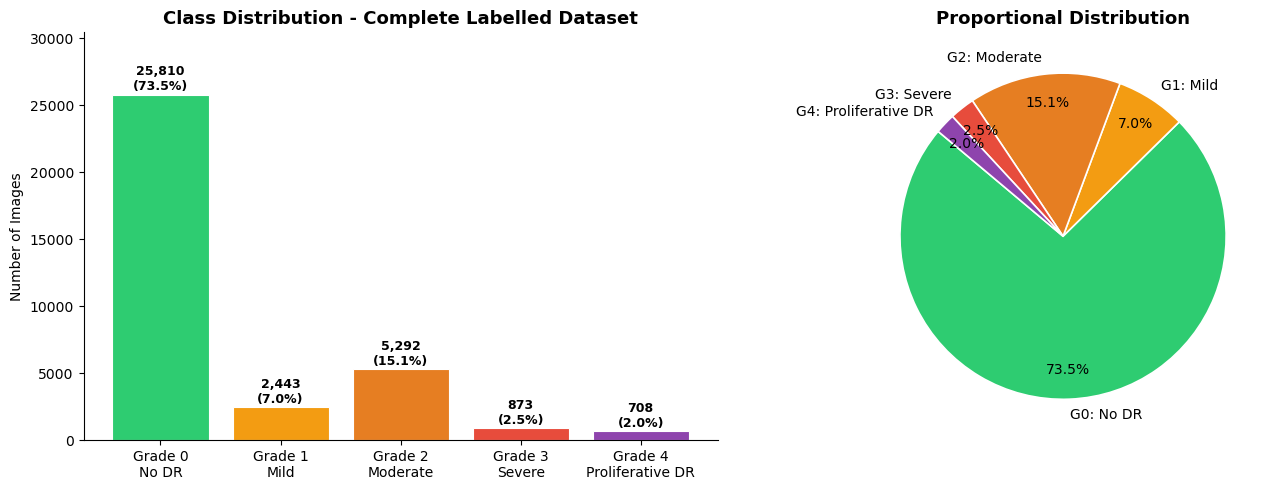

Saved -> results/figures/data_preparation/01_overall_class_distribution.png


In [7]:

# Class counts on the complete labelled dataset
overall_counts = df['level'].value_counts().sort_index()
overall_pcts   = (overall_counts / len(df) * 100).round(2)

print('CLASS DISTRIBUTION - COMPLETE LABELLED DATASET')
print('=' * 55)
for g, cnt, pct in zip(overall_counts.index, overall_counts.values, overall_pcts.values):
    bar = '#' * int(pct)
    print(f'  Grade {g} | {CLASS_NAMES[g]:18s} | {cnt:6,} ({pct:5.1f}%) {bar}')
print('=' * 55)
print(f'  TOTAL                       | {len(df):6,} (100.0%)')
print(f'\nImbalance ratio (max/min): {overall_counts.max()/overall_counts.min():.1f}x')

# Figure: overall class distribution (bar + pie)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar([f'Grade {i}\n{CLASS_NAMES[i]}' for i in range(NUM_CLASSES)],
              overall_counts.values, color=CLASS_COLORS, edgecolor='white', linewidth=0.8)
for bar, cnt, pct in zip(bars, overall_counts.values, overall_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Class Distribution - Complete Labelled Dataset', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, overall_counts.max() * 1.18)

ax2 = axes[1]
ax2.pie(overall_counts.values, labels=[f'G{i}: {CLASS_NAMES[i]}' for i in range(NUM_CLASSES)],
        colors=CLASS_COLORS, autopct='%1.1f%%', startangle=140, pctdistance=0.82,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
ax2.set_title('Proportional Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_overall_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> results/figures/data_preparation/01_overall_class_distribution.png')


Resolution / brightness summary (n=300 images, 60 per grade x 5 grades):
  Width      : min=1600, max=4928, mean=3644
  Height     : min=1184, max=3264, mean=2479
  Brightness : min=9.5, max=130.0, mean=59.2 (0-255 scale)


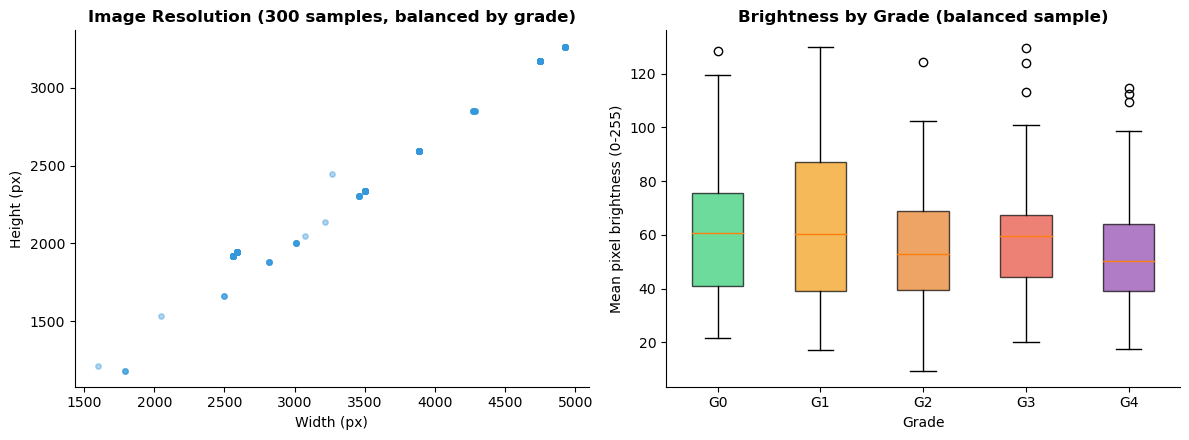

Saved -> results/figures/data_preparation/02_resolution_brightness_summary.png


In [8]:

# Brightness & resolution summary (equal sample per grade)
SAMPLES_PER_GRADE = 60

sample_df = pd.concat(
    [
        df[df['level'] == grade].sample(
            n=min(SAMPLES_PER_GRADE, len(df[df['level'] == grade])),
            random_state=RANDOM_SEED,
        )
        for grade in range(NUM_CLASSES)
    ],
    ignore_index=True,
)

widths, heights, brightness, grades = [], [], [], []
failed_quality_checks = []

for _, row in sample_df.iterrows():
    try:
        with Image.open(row['filepath']) as img:
            img.verify()

        with Image.open(row['filepath']) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            brightness.append(
                ImageStat.Stat(img.convert('L')).mean[0]
            )
            grades.append(row['level'])

    except Exception as exc:
        failed_quality_checks.append(
            {
                'image': row['image'],
                'error': str(exc),
            }
        )

if failed_quality_checks:
    raise RuntimeError(
        f'{len(failed_quality_checks)} sampled images could not be read. '
        f'Examples: {failed_quality_checks[:3]}'
    )

print(f'Resolution / brightness summary (n={len(widths)} images, '
      f'{SAMPLES_PER_GRADE} per grade x {NUM_CLASSES} grades):')
print(f'  Width      : min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}')
print(f'  Height     : min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}')
print(f'  Brightness : min={min(brightness):.1f}, max={max(brightness):.1f}, '
      f'mean={np.mean(brightness):.1f} (0-255 scale)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(widths, heights, alpha=0.4, s=15, color='#3498DB')
axes[0].set_xlabel('Width (px)'); axes[0].set_ylabel('Height (px)')
axes[0].set_title(f'Image Resolution ({len(widths)} samples, balanced by grade)', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

bp_data = [[b for b, g in zip(brightness, grades) if g == grade] for grade in range(NUM_CLASSES)]
bp = axes[1].boxplot(bp_data, patch_artist=True)
for patch, color in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_xticklabels([f'G{i}' for i in range(NUM_CLASSES)])
axes[1].set_xlabel('Grade'); axes[1].set_ylabel('Mean pixel brightness (0-255)')
axes[1].set_title('Brightness by Grade (balanced sample)', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_resolution_brightness_summary.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved -> results/figures/data_preparation/02_resolution_brightness_summary.png')


## 7. Patient-grouped train / validation / internal-test split

Images are split by **`patient_id`** using `GroupShuffleSplit`, which guarantees every image
belonging to a given patient goes to the same partition — both eyes of a patient always end
up in the same set. This matters because the two eyes of a patient share anatomy, imaging
conditions, and often DR grade, so splitting them across partitions would leak
patient-specific information from training into evaluation.

Because `GroupShuffleSplit` does not support stratification directly, we **search over many
random seeds** and keep the split whose resulting class proportions are closest (in total
absolute deviation) to the overall class distribution from Section 6. This gives group-safety
*and* proportions close to what a stratified split would produce.

Target split sizes are **70% train / 15% validation / 15% internal test**, measured in
images. The internal test set is entirely separate from, and much smaller than, the official
(unlabelled) Kaggle test set — it exists purely so this project has a held-out, labelled
evaluation set that is never touched during model development.


In [9]:

def best_grouped_split(frame: pd.DataFrame, group_col: str, label_col: str,
                        test_size: float, n_trials: int = 300, seed: int = RANDOM_SEED):
    '''Repeated GroupShuffleSplit: try many seeds, keep the split whose held-out
    class distribution is closest to the full-frame class distribution.

    Returns (idx_keep, idx_holdout, chosen_seed, distribution_score).
    '''
    overall_dist = frame[label_col].value_counts(normalize=True).sort_index()
    best_score = np.inf
    best = None

    for trial in range(n_trials):
        trial_seed = seed + trial
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=trial_seed)
        idx_keep, idx_holdout = next(gss.split(frame, groups=frame[group_col]))

        holdout_dist = (frame.iloc[idx_holdout][label_col]
                         .value_counts(normalize=True)
                         .reindex(overall_dist.index, fill_value=0.0))
        score = float(np.abs(holdout_dist - overall_dist).sum())

        if score < best_score:
            best_score = score
            best = (idx_keep, idx_holdout, trial_seed)

    return (*best, best_score)


# Step 1: carve off the internal test partition (15%)
idx_trainval, idx_test, seed_test, score_test = best_grouped_split(
    df, group_col='patient_id', label_col='level',
    test_size=TEST_RATIO, n_trials=300, seed=RANDOM_SEED,
)
trainval_df = df.iloc[idx_trainval].reset_index(drop=True)
test_df     = df.iloc[idx_test].reset_index(drop=True)

# Step 2: split remaining 85% into train (70%) and validation (15%)
val_fraction_of_remainder = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
idx_train, idx_val, seed_val, score_val = best_grouped_split(
    trainval_df, group_col='patient_id', label_col='level',
    test_size=val_fraction_of_remainder, n_trials=300, seed=RANDOM_SEED,
)
train_df = trainval_df.iloc[idx_train].reset_index(drop=True)
val_df   = trainval_df.iloc[idx_val].reset_index(drop=True)

train_df = train_df.assign(split='train')
val_df   = val_df.assign(split='val')
test_df  = test_df.assign(split='internal_test')

print(f'Test split search        : best seed={seed_test}, distribution deviation={score_test:.4f}')
print(f'Validation split search  : best seed={seed_val}, distribution deviation={score_val:.4f}')
print()
print(f'{"Partition":<14} {"Images":>8} {"Patients":>10}')
print('-' * 36)
for name, part in [('train', train_df), ('val', val_df), ('internal_test', test_df)]:
    print(f'{name:<14} {len(part):>8,} {part["patient_id"].nunique():>10,}')
print('-' * 36)
total_images   = len(train_df) + len(val_df) + len(test_df)
total_patients = df['patient_id'].nunique()
print(f'{"total":<14} {total_images:>8,} {total_patients:>10,}')

# Actual split proportions (relative to the complete labelled dataset)
total = len(df)
print()
print(f'Train proportion         : {len(train_df) / total:.4f}  (target {TRAIN_RATIO:.4f})')
print(f'Validation proportion    : {len(val_df) / total:.4f}  (target {VAL_RATIO:.4f})')
print(f'Internal test proportion : {len(test_df) / total:.4f}  (target {TEST_RATIO:.4f})')


Test split search        : best seed=203, distribution deviation=0.0029
Validation split search  : best seed=154, distribution deviation=0.0033

Partition        Images   Patients
------------------------------------
train            24,586     12,293
val               5,270      2,635
internal_test     5,270      2,635
------------------------------------
total            35,126     17,563

Train proportion         : 0.6999  (target 0.7000)
Validation proportion    : 0.1500  (target 0.1500)
Internal test proportion : 0.1500  (target 0.1500)


In [10]:

# Assert actual split ratios are within tolerance of the targets
actual_ratios = {
    "train": len(train_df) / len(df),
    "validation": len(val_df) / len(df),
    "internal_test": len(test_df) / len(df),
}

target_ratios = {
    "train": TRAIN_RATIO,
    "validation": VAL_RATIO,
    "internal_test": TEST_RATIO,
}

MAX_RATIO_DEVIATION = 0.01

for partition in target_ratios:
    deviation = abs(
        actual_ratios[partition]
        - target_ratios[partition]
    )

    assert deviation <= MAX_RATIO_DEVIATION, (
        f"{partition} ratio differs from its target by "
        f"{deviation:.4f}, above the permitted "
        f"{MAX_RATIO_DEVIATION:.4f}."
    )

print("PASSED: split sizes are within 1% of their targets.")


PASSED: split sizes are within 1% of their targets.


## 8. Split-integrity, leakage and class-coverage checks

Three properties must hold for the split to be usable, and all three are **asserted**, not
just printed, so the notebook fails immediately if any of them is ever violated:

1. **No patient appears in more than one partition.**
2. **Every image appears in exactly one partition** (no row dropped, none duplicated).
3. **Every partition contains at least one example of every class.** A partition missing an
   entire grade would make per-class validation/test metrics undefined for that grade, and
   would also make it impossible to compute a meaningful class-weighted loss consistently
   across partitions.


In [11]:

train_patients = set(train_df['patient_id'])
val_patients   = set(val_df['patient_id'])
test_patients  = set(test_df['patient_id'])

train_val_overlap  = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap   = val_patients & test_patients

print('PATIENT-LEVEL LEAKAGE CHECK')
print('=' * 42)
print(f'Train-validation patient overlap : {len(train_val_overlap)}')
print(f'Train-test patient overlap       : {len(train_test_overlap)}')
print(f'Validation-test patient overlap  : {len(val_test_overlap)}')
print('=' * 42)

assert train_patients.isdisjoint(val_patients),  'Leakage: train/val share patients!'
assert train_patients.isdisjoint(test_patients), 'Leakage: train/test share patients!'
assert val_patients.isdisjoint(test_patients),   'Leakage: val/test share patients!'
print('PASSED: train / val / internal-test patient sets are pairwise disjoint.')


PATIENT-LEVEL LEAKAGE CHECK
Train-validation patient overlap : 0
Train-test patient overlap       : 0
Validation-test patient overlap  : 0
PASSED: train / val / internal-test patient sets are pairwise disjoint.


In [12]:

# Every image appears in exactly one partition
all_split_df    = pd.concat([train_df, val_df, test_df], ignore_index=True)
n_total_images  = len(df)
n_split_images  = len(all_split_df)
n_unique_images = all_split_df['image'].nunique()

assert n_split_images == n_total_images, (
    f'Row-count mismatch: splits contain {n_split_images:,} rows, expected {n_total_images:,}.'
)
assert n_unique_images == n_split_images, 'Duplicate images detected across partitions!'
print(f'PASSED: all {n_total_images:,} labelled images appear in exactly one partition '
      f'(train + val + internal_test), with no duplicates.')

# Every partition contains every class
for name, frame in [('train', train_df), ('validation', val_df), ('internal_test', test_df)]:
    missing_classes = set(range(NUM_CLASSES)) - set(frame['level'].unique())
    assert not missing_classes, f'{name} is missing classes: {missing_classes}'

print('PASSED: all five classes (0-4) are present in every partition '
      '(train, validation, internal_test).')


PASSED: all 35,126 labelled images appear in exactly one partition (train + val + internal_test), with no duplicates.
PASSED: all five classes (0-4) are present in every partition (train, validation, internal_test).


## 9. Save split manifests and split metadata

**No images are moved or copied.** All labelled images remain in the single `train/` folder
on disk. The only artefacts produced here are CSV manifests listing, for each partition,
which `image` / `filepath` belongs to it, plus a small metadata file recording exactly how
the split was chosen.

Manifests are sorted by `patient_id`, then `eye`, before saving — this keeps both eyes of the
same patient adjacent in the file, makes diffs between re-runs easy to read, and gives a
deterministic row order independent of the internal shuffling used during the search.

The internal test manifest is named **`internal_test_split.csv`**, not `test_split.csv`, to
avoid any confusion with the official (unlabelled) Kaggle test set — this project never
produces a file simply called "test" that could be mistaken for that set.

Saved here:

- `configs/splits/train_split.csv`
- `configs/splits/val_split.csv`
- `configs/splits/internal_test_split.csv`
- `configs/split_metadata.json` — chosen seeds, distribution-deviation scores, and target vs.
  actual split ratios, for reproducibility and experiment tracking
- `results/tables/split_summary.csv` — image and patient counts per partition
- `results/tables/class_distribution.csv` — class counts/proportions for the complete
  dataset and for each partition


In [13]:

MANIFEST_COLS = ['image', 'level', 'patient_id', 'eye', 'filepath']

# Sort manifests before saving
train_df = train_df.sort_values(['patient_id', 'eye']).reset_index(drop=True)
val_df   = val_df.sort_values(['patient_id', 'eye']).reset_index(drop=True)
test_df  = test_df.sort_values(['patient_id', 'eye']).reset_index(drop=True)

train_csv_path = SPLITS_DIR / 'train_split.csv'
val_csv_path   = SPLITS_DIR / 'val_split.csv'
test_csv_path  = SPLITS_DIR / 'internal_test_split.csv'

train_df[MANIFEST_COLS].to_csv(train_csv_path, index=False)
val_df[MANIFEST_COLS].to_csv(val_csv_path, index=False)
test_df[MANIFEST_COLS].to_csv(test_csv_path, index=False)

print('Saved split manifests (images were NOT moved on disk):')
print(f'  {train_csv_path}  ({len(train_df):,} rows)')
print(f'  {val_csv_path}  ({len(val_df):,} rows)')
print(f'  {test_csv_path}  ({len(test_df):,} rows)')


Saved split manifests (images were NOT moved on disk):
  /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/configs/splits/train_split.csv  (24,586 rows)
  /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/configs/splits/val_split.csv  (5,270 rows)
  /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/configs/splits/internal_test_split.csv  (5,270 rows)


In [14]:

# Split metadata: seeds, distribution scores, target vs. actual ratios
split_metadata = {
    'random_seed_start': RANDOM_SEED,
    'selected_test_seed': int(seed_test),
    'selected_validation_seed': int(seed_val),
    'test_distribution_deviation': float(score_test),
    'validation_distribution_deviation': float(score_val),
    'target_ratios': {
        'train': TRAIN_RATIO,
        'validation': VAL_RATIO,
        'internal_test': TEST_RATIO,
    },
    'actual_ratios': {
        'train': len(train_df) / len(df),
        'validation': len(val_df) / len(df),
        'internal_test': len(test_df) / len(df),
    },
}

split_metadata_path = CONFIG_DIR / 'split_metadata.json'
with open(split_metadata_path, 'w') as f:
    json.dump(split_metadata, f, indent=2)

print(f'Saved -> {split_metadata_path}')
print(json.dumps(split_metadata, indent=2))


Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/configs/split_metadata.json
{
  "random_seed_start": 42,
  "selected_test_seed": 203,
  "selected_validation_seed": 154,
  "test_distribution_deviation": 0.002940674077522659,
  "validation_distribution_deviation": 0.0032591098881207467,
  "target_ratios": {
    "train": 0.7,
    "validation": 0.15,
    "internal_test": 0.15
  },
  "actual_ratios": {
    "train": 0.6999373683311507,
    "validation": 0.15003131583442464,
    "internal_test": 0.15003131583442464
  }
}


In [15]:

# Split summary table (images + patients per partition)
split_summary = pd.DataFrame([
    {'partition': 'train',         'images': len(train_df), 'patients': train_df['patient_id'].nunique()},
    {'partition': 'val',           'images': len(val_df),   'patients': val_df['patient_id'].nunique()},
    {'partition': 'internal_test', 'images': len(test_df),  'patients': test_df['patient_id'].nunique()},
    {'partition': 'total',         'images': len(df),       'patients': df['patient_id'].nunique()},
])
split_summary_path = TABLES_DIR / 'split_summary.csv'
split_summary.to_csv(split_summary_path, index=False)
print(f'Saved -> {split_summary_path}')
split_summary


Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/tables/split_summary.csv


,partition,images,patients
0,train,24586,12293
1,val,5270,2635
2,internal_test,5270,2635
3,total,35126,17563


In [16]:

# Class distribution table: complete dataset + each partition
def class_dist_row(frame, partition_name):
    counts = frame['level'].value_counts().reindex(range(NUM_CLASSES), fill_value=0).sort_index()
    props  = (counts / counts.sum()).round(4)
    return pd.DataFrame({
        'partition': partition_name,
        'level': counts.index,
        'class_name': [CLASS_NAMES[i] for i in counts.index],
        'count': counts.values,
        'proportion': props.values,
    })

class_distribution = pd.concat([
    class_dist_row(df,       'complete'),
    class_dist_row(train_df, 'train'),
    class_dist_row(val_df,   'val'),
    class_dist_row(test_df,  'internal_test'),
], ignore_index=True)

class_dist_path = TABLES_DIR / 'class_distribution.csv'
class_distribution.to_csv(class_dist_path, index=False)
print(f'Saved -> {class_dist_path}')
class_distribution


Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/tables/class_distribution.csv


,partition,level,class_name,count,proportion
0,complete,0,No DR,25810,0.7348
1,complete,1,Mild,2443,0.0695
2,complete,2,Moderate,5292,0.1507
3,complete,3,Severe,873,0.0249
4,complete,4,Proliferative DR,708,0.0202
5,train,0,No DR,18062,0.7346
6,train,1,Mild,1709,0.0695
7,train,2,Moderate,3698,0.1504
8,train,3,Severe,610,0.0248
9,train,4,Proliferative DR,507,0.0206


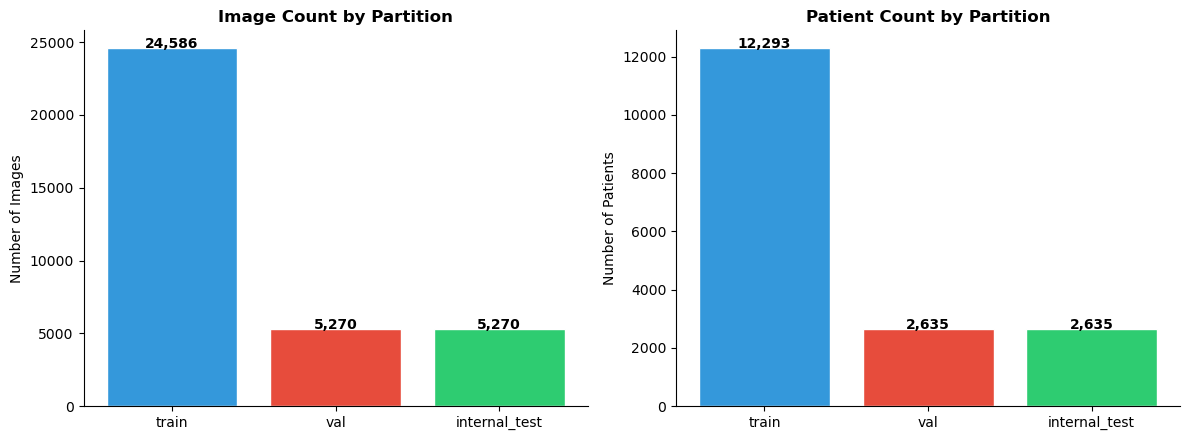

Saved -> results/figures/data_preparation/03_partition_counts.png


In [17]:

# Visual: patient-count and image-count summary by partition
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
partitions = ['train', 'val', 'internal_test']
part_colors = ['#3498DB', '#E74C3C', '#2ECC71']

img_counts = [len(train_df), len(val_df), len(test_df)]
pat_counts = [train_df['patient_id'].nunique(), val_df['patient_id'].nunique(),
              test_df['patient_id'].nunique()]

ax = axes[0]
bars = ax.bar(partitions, img_counts, color=part_colors, edgecolor='white')
for b, v in zip(bars, img_counts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+30, f'{v:,}', ha='center', fontweight='bold')
ax.set_title('Image Count by Partition', fontweight='bold')
ax.set_ylabel('Number of Images')
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
bars = ax.bar(partitions, pat_counts, color=part_colors, edgecolor='white')
for b, v in zip(bars, pat_counts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+15, f'{v:,}', ha='center', fontweight='bold')
ax.set_title('Patient Count by Partition', fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_partition_counts.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved -> results/figures/data_preparation/03_partition_counts.png')


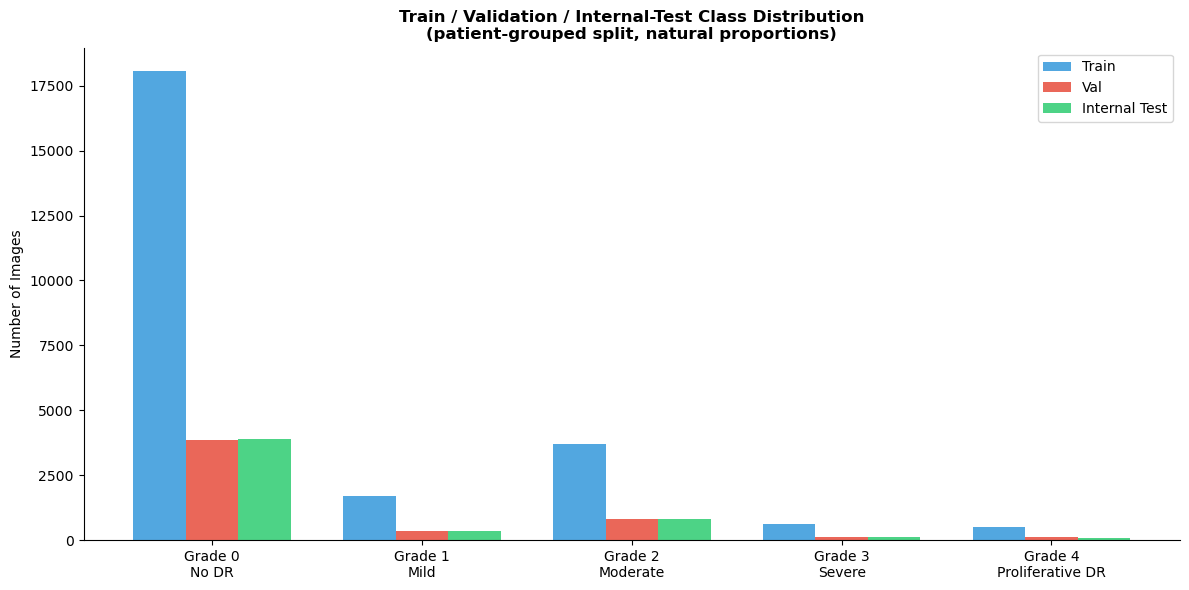

Saved -> results/figures/data_preparation/04_train_val_test_distribution.png

Note: distributions are left natural. No oversampling or duplication of minority
classes has been applied to validation, internal-test, or training data.


In [18]:

# Visual: class distribution comparison across partitions
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(NUM_CLASSES)
w = 0.25

for offset, (name, frame, color) in enumerate([
    ('Train', train_df, '#3498DB'), ('Val', val_df, '#E74C3C'), ('Internal Test', test_df, '#2ECC71')
]):
    counts = frame['level'].value_counts().reindex(range(NUM_CLASSES), fill_value=0).sort_index()
    ax.bar(x + (offset - 1) * w, counts.values, w, label=name, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Grade {i}\n{CLASS_NAMES[i]}' for i in range(NUM_CLASSES)])
ax.set_ylabel('Number of Images')
ax.set_title('Train / Validation / Internal-Test Class Distribution\n'
             '(patient-grouped split, natural proportions)', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_train_val_test_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> results/figures/data_preparation/04_train_val_test_distribution.png')
print()
print('Note: distributions are left natural. No oversampling or duplication of minority')
print('classes has been applied to validation, internal-test, or training data.')


## 10. Basic preprocessing function (P0)

**P0 is the conservative baseline.** It avoids anything aggressive (no CLAHE, no vessel
enhancement, no colour-channel boosting) so its effect on downstream model performance is
easy to interpret in isolation.

**P0 steps:**

1. Load image, convert to RGB.
2. Crop black outer borders (contour-based).
3. Pad the cropped retinal area onto a square canvas, centred.
4. Resize to 224 x 224.
5. Keep all three RGB channels (no colour manipulation).

`_common_preprocessing()` implements steps 1-3 and is reused, unchanged, by both P0 (this
section) and P1 (Section 11) — this is what makes the two variants a clean, single-factor
comparison rather than two independently-written pipelines that happen to look similar.

Tensor conversion and ImageNet normalisation are **not** performed here; they belong to the
`Dataset`/`DataLoader` used for model training.


In [19]:

P0_SIZE = 224  # final square output size for P0 / P1


def _load_rgb(path: str) -> np.ndarray:
    '''Load an image file and return it as an RGB uint8 array.'''
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise ValueError(f'Cannot decode image: {path}')
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def _crop_black_borders(img: np.ndarray, threshold: int = 10) -> np.ndarray:
    '''Crop the uninformative black padding around the retinal disc.'''
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    margin = int(min(w, h) * 0.02)
    x, y = max(0, x - margin), max(0, y - margin)
    w = min(img.shape[1] - x, w + 2 * margin)
    h = min(img.shape[0] - y, h + 2 * margin)
    return img[y:y + h, x:x + w]


def _pad_square(img: np.ndarray) -> np.ndarray:
    '''Pad an image onto a centred square canvas (no resizing yet).'''
    h, w = img.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=img.dtype)
    y = (side - h) // 2
    x = (side - w) // 2
    canvas[y:y + h, x:x + w] = img
    return canvas


def _common_preprocessing(image_path: str) -> np.ndarray:
    '''Load the RGB image and crop the black outer border.'''
    img = _load_rgb(image_path)
    img = _crop_black_borders(img)
    return img


def preprocess_p0(
    image_path: str,
    output_size: int = P0_SIZE,
) -> np.ndarray:
    '''P0: crop, pad to square and resize.'''
    img = _common_preprocessing(image_path)
    img = _pad_square(img)

    return cv2.resize(
        img,
        (output_size, output_size),
        interpolation=cv2.INTER_AREA,
    )


print(f'P0 (basic) preprocessing ready. Output size: {P0_SIZE}x{P0_SIZE}, RGB, uint8.')


P0 (basic) preprocessing ready. Output size: 224x224, RGB, uint8.


## 11. Ben Graham preprocessing function (P1)

**P1 = `_common_preprocessing()` + Ben Graham + resize.** It calls the exact same
`_common_preprocessing()` function as P0, so the *only* difference between the two functions
is the Ben Graham step inserted in between. This is what makes a later P0-vs-P1 performance
ablation meaningful: any difference in outcome can be attributed to Ben Graham specifically,
not to incidental differences in cropping or padding logic.

Ben Graham's technique (from the original Kaggle DR competition) is a local-contrast
enhancement implemented as an unsharp mask against a heavily blurred copy of the image:
`addWeighted(img, 4, blur, -4, 128)`.

This notebook only *produces and visualises* P0 and P1 — it does not evaluate model
performance. Both variants are **prepared for a later performance ablation** in the training
notebook, where actual validation metrics will determine whether Ben Graham helps, hurts, or
makes no difference for this task.


In [20]:

def ben_graham(img: np.ndarray, sigma: float = 10) -> np.ndarray:
    '''Ben Graham local-contrast enhancement (Kaggle DR competition winner's technique).'''
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 4, blurred, -4, 128)


def preprocess_p1(
    image_path: str,
    output_size: int = P0_SIZE,
    sigma: float = 10,
) -> np.ndarray:
    '''P1: P0 with Ben Graham enhancement added before padding.'''
    img = _common_preprocessing(image_path)
    img = ben_graham(img, sigma=sigma)
    img = _pad_square(img)

    return cv2.resize(
        img,
        (output_size, output_size),
        interpolation=cv2.INTER_AREA,
    )


print('P1 (Ben Graham) preprocessing ready - shares _common_preprocessing() with P0; '
      'Ben Graham is now applied before padding, so the artificial black border is not enhanced.')


P1 (Ben Graham) preprocessing ready - shares _common_preprocessing() with P0; Ben Graham is now applied before padding, so the artificial black border is not enhanced.


## 12. Preprocessing visual comparison

One sample image per grade (0-4), drawn from the training partition, shown as
**Original vs P0 vs P1** so the effect of the single Ben Graham step can be inspected directly
against the conservative baseline.

As noted above, this is a **visual sanity check only** — it confirms the two functions behave
as intended and produce plausible output, not that either one improves model performance.
That comparison happens later, using validation metrics from the training notebook.


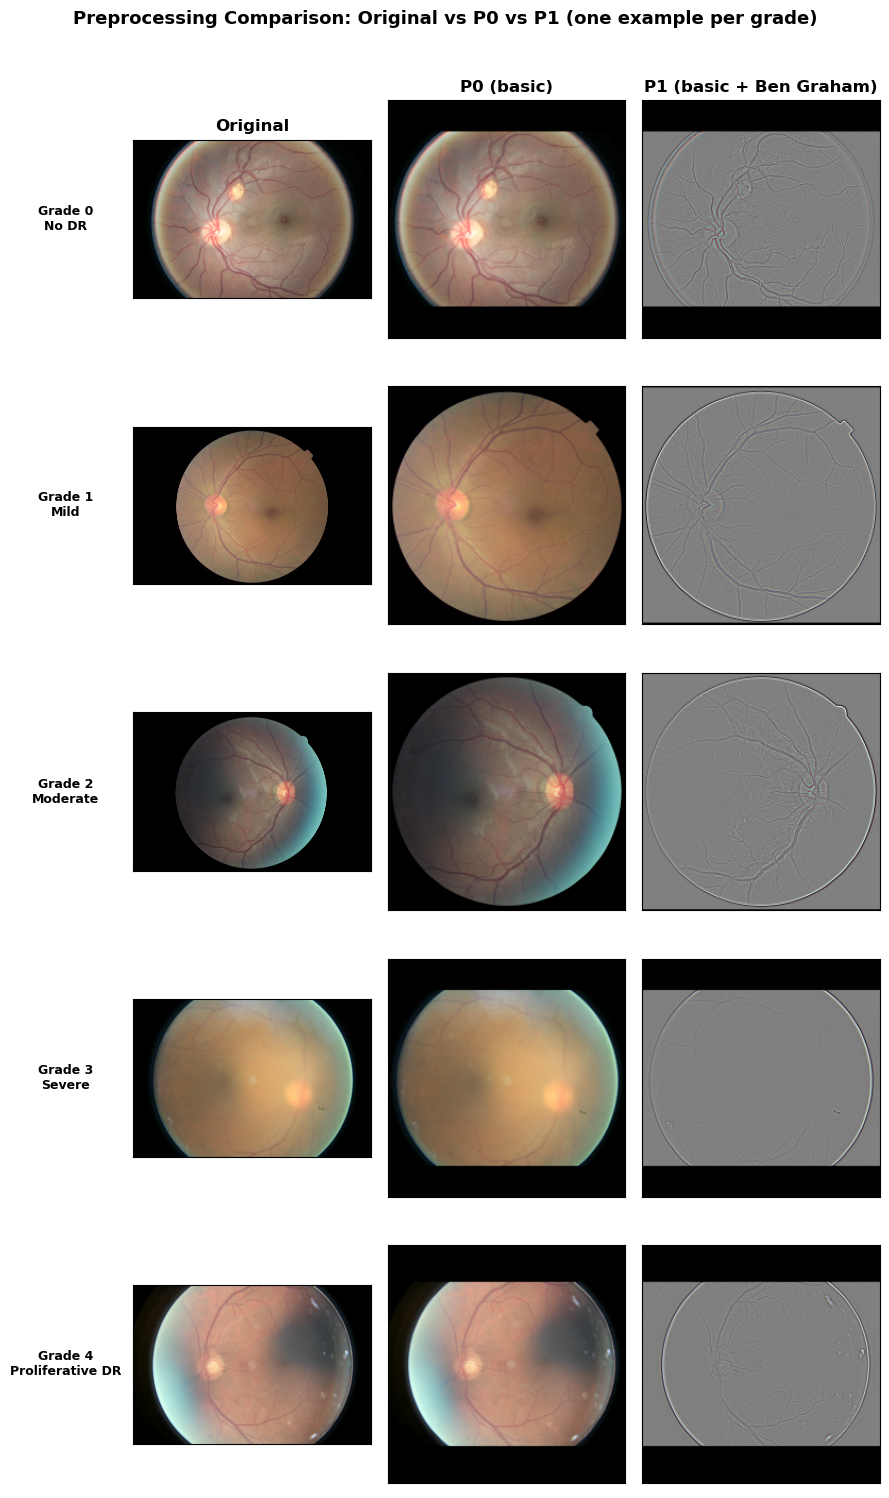

Saved -> results/figures/data_preparation/05_p0_vs_p1_comparison.png


In [21]:

example_rows = [
    train_df[train_df['level'] == g].sample(1, random_state=RANDOM_SEED).iloc[0]
    for g in range(NUM_CLASSES)
]

fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(9, NUM_CLASSES * 3))

for i, row in enumerate(example_rows):
    orig = _load_rgb(row['filepath'])
    p0_img = preprocess_p0(row['filepath'])
    p1_img = preprocess_p1(row['filepath'])

    axes[i][0].imshow(orig)
    axes[i][1].imshow(p0_img)
    axes[i][2].imshow(p1_img)

    axes[i][0].set_ylabel(f"Grade {row['level']}\n{CLASS_NAMES[row['level']]}",
                           fontsize=9, fontweight='bold', rotation=0, labelpad=45, va='center')
    for ax in axes[i]:
        ax.set_xticks([]); ax.set_yticks([])

axes[0][0].set_title('Original', fontweight='bold')
axes[0][1].set_title('P0 (basic)', fontweight='bold')
axes[0][2].set_title('P1 (basic + Ben Graham)', fontweight='bold')

plt.suptitle('Preprocessing Comparison: Original vs P0 vs P1 (one example per grade)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_p0_vs_p1_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved -> results/figures/data_preparation/05_p0_vs_p1_comparison.png')


### A note on augmentation (intentionally not implemented here)

Everything above is **deterministic**: the same input image always produces the same output
array. Random data augmentation is a *training-time* concern and is deliberately excluded from
this notebook — applying it once and saving the result would fix a single random draw
permanently instead of resampling it every epoch, and applying it to validation or
internal-test data would make evaluation non-deterministic and harder to compare across runs.

The training notebook's `Dataset`/`DataLoader` is expected to apply randomness **only to the
training partition**, for example:

```python
# Reference only - implemented in the training notebook, not here.
train_augmentations = [
    'horizontal_flip',
    'small_rotation',          # e.g. +/- 10-15 degrees
    'mild_scale_translate',    # small zoom / shift
    'mild_brightness_contrast',
    'low_probability_blur',    # applied rarely
]
# Validation and internal-test transforms: resize/normalise only, no randomness.
```

`train_split.csv`, `val_split.csv` and `internal_test_split.csv` all point at the **same,
unmodified** original images on disk; augmentation state is never baked into any file this
notebook produces.


## 13. Training-only class-weight calculations

All statistics in this section are computed **from the training partition only**
(`train_df`). Validation and internal-test class distributions are left untouched (natural,
as saved in Section 9) and are never used to derive weights — using them here would leak
information about the evaluation sets into a quantity that ultimately influences training.

Three weighting schemes are computed, all intended for later loss-function experiments in a
training notebook rather than for this notebook itself:

1. **Inverse-frequency weights** — `w_c = 1 / n_c`, normalised so the mean weight is 1.
2. **Clipped balanced weights** — a class-balanced weight,
   `w_c = N / (num_classes * n_c)`, clipped to the range **[0.5, 2.5]**. This range keeps
   the reweighting mild enough that the loss cannot be dominated by a handful of rare-class
   examples, while still giving under-represented classes a meaningfully larger weight than
   the majority class.
3. **Effective-number (Class-Balanced) weights**, from Cui et al. (2019):

$$w_c = \frac{1 - \beta}{1 - \beta^{n_c}}$$

where $n_c$ is the number of training examples in class $c$, and $\beta \in [0, 1)$ controls
how strongly class frequency affects the weight (as $\beta \to 1$, weights approach pure
inverse-frequency; as $\beta \to 0$, weights approach uniform). Inverse-frequency and
effective-number weights are normalised to an arithmetic mean of approximately 1. The
clipped balanced weights retain their bounded range of [0.5, 2.5] to reproduce the previous
coursework method.

`BETAS[0] = 0.999` below is an **initial** effective-number setting, not a tuned default. A
second value, `0.9999`, is also computed so that a later training notebook can compare both
against validation performance rather than assuming one is better without evidence.

**Ben Graham is a preprocessing step, not a class-imbalance method** — it is handled entirely
in Sections 10-12 and plays no role in the weights computed here.


In [22]:

BETAS = [0.999, 0.9999]      # 0.999 is the initial effective-number setting; 0.9999 is
                              # computed alongside it for comparison in a later training notebook.
CLIP_LOWER = 0.5
CLIP_UPPER = 2.5

train_counts = (train_df['level'].value_counts()
                .reindex(range(NUM_CLASSES), fill_value=0)
                .sort_index())
train_props = (train_counts / train_counts.sum())

print('TRAINING-SET CLASS COUNTS (used for all weighting below)')
print('=' * 50)
for g in range(NUM_CLASSES):
    print(f'  Grade {g} | {CLASS_NAMES[g]:18s} | {train_counts[g]:6,} '
          f'({train_props[g]*100:5.1f}%)')
print('=' * 50)

# 1. Inverse-frequency weights
inv_freq = 1.0 / train_counts.replace(0, np.nan)
inv_freq_weights = (inv_freq / inv_freq.mean()).fillna(0.0)

# 2. Clipped balanced weights: w_c = N / (num_classes * n_c), clipped to [0.5, 2.5]
raw_balanced_weights = len(train_df) / (NUM_CLASSES * train_counts)
clipped_weights = raw_balanced_weights.clip(lower=CLIP_LOWER, upper=CLIP_UPPER)

# 3. Effective-number (Class-Balanced) weights, for each candidate beta
cb_weights_by_beta = {}
for beta in BETAS:
    effective_num = 1.0 - np.power(beta, train_counts.replace(0, np.nan))
    cb_weights = (1.0 - beta) / effective_num
    cb_weights = (cb_weights / cb_weights.mean()).fillna(0.0)
    cb_weights_by_beta[beta] = cb_weights

weights_table = pd.DataFrame({
    'level': range(NUM_CLASSES),
    'class_name': [CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    'train_count': train_counts.values,
    'train_proportion': train_props.round(4).values,
    'inverse_frequency_weight': inv_freq_weights.round(4).values,
    'raw_balanced_weight': raw_balanced_weights.round(4).values,
    'clipped_weight': clipped_weights.round(4).values,
})
for beta in BETAS:
    weights_table[f'effective_number_weight_beta_{beta}'] = cb_weights_by_beta[beta].round(4).values

weights_table


TRAINING-SET CLASS COUNTS (used for all weighting below)
  Grade 0 | No DR              | 18,062 ( 73.5%)
  Grade 1 | Mild               |  1,709 (  7.0%)
  Grade 2 | Moderate           |  3,698 ( 15.0%)
  Grade 3 | Severe             |    610 (  2.5%)
  Grade 4 | Proliferative DR   |    507 (  2.1%)


,level,class_name,train_count,train_proportion,inverse_frequency_weight,raw_balanced_weight,clipped_weight,effective_number_weight_beta_0.999,effective_number_weight_beta_0.9999
0,0,No DR,18062,0.7346,0.0612,0.2722,0.5000,0.6290,0.1248
1,1,Mild,1709,0.0695,0.6469,2.8772,2.5000,0.7679,0.6641
2,2,Moderate,3698,0.1504,0.2990,1.3297,1.3297,0.6450,0.3375
3,3,Severe,610,0.0248,1.8124,8.0610,2.5000,1.3770,1.7631
4,4,Proliferative DR,507,0.0206,2.1806,9.6986,2.5000,1.5811,2.1104


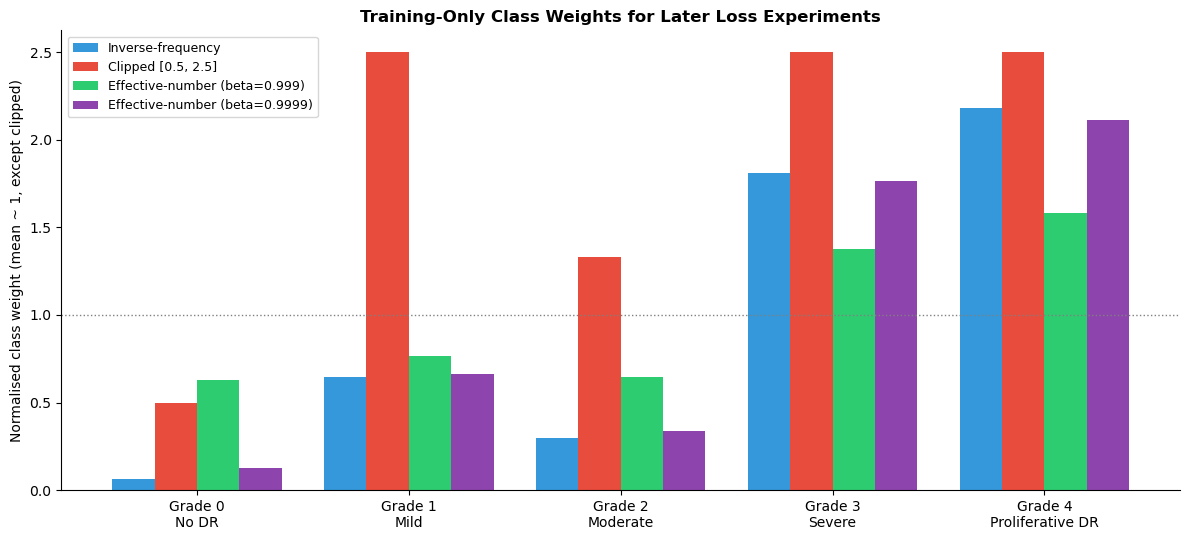

Saved -> results/figures/data_preparation/06_class_weight_schemes.png


In [23]:

# Visual: the weighting schemes side by side
fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(NUM_CLASSES)
w = 0.2

ax.bar(x - 1.5*w, weights_table['inverse_frequency_weight'], w,
       label='Inverse-frequency', color='#3498DB')
ax.bar(x - 0.5*w, weights_table['clipped_weight'], w,
       label=f'Clipped [{CLIP_LOWER}, {CLIP_UPPER}]', color='#E74C3C')
for i, beta in enumerate(BETAS):
    ax.bar(x + (0.5 + i) * w, weights_table[f'effective_number_weight_beta_{beta}'], w,
           label=f'Effective-number (beta={beta})',
           color='#2ECC71' if i == 0 else '#8E44AD')

ax.set_xticks(x)
ax.set_xticklabels([f'Grade {i}\n{CLASS_NAMES[i]}' for i in range(NUM_CLASSES)])
ax.set_ylabel('Normalised class weight (mean ~ 1, except clipped)')
ax.set_title('Training-Only Class Weights for Later Loss Experiments', fontweight='bold')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_class_weight_schemes.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved -> results/figures/data_preparation/06_class_weight_schemes.png')


## 14. Save class statistics and figures

All figures produced above are already saved incrementally to
`results/figures/data_preparation/`. This section saves the single consolidated
`configs/class_statistics.json`, the only class-imbalance artefact a training notebook needs
to read for loss-function weighting.


In [24]:

class_statistics = {
    'random_seed': RANDOM_SEED,
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'source_partition': 'train',
    'training_class_counts': {int(k): int(v) for k, v in train_counts.items()},
    'training_class_proportions': {int(k): float(v) for k, v in train_props.items()},
    'inverse_frequency_weights': {int(k): float(v) for k, v in inv_freq_weights.items()},
    'clipped_weights': {
        'formula': 'N / (num_classes * n_c), clipped',
        'clip_lower': CLIP_LOWER,
        'clip_upper': CLIP_UPPER,
        'weights': {int(k): float(v) for k, v in clipped_weights.items()},
    },
    'effective_number_weights': {
        'formula': '(1 - beta) / (1 - beta ** n_c), normalised to mean ~ 1',
        'initial_beta': BETAS[0],
        'by_beta': {
            str(beta): {int(k): float(v) for k, v in cb_weights_by_beta[beta].items()}
            for beta in BETAS
        },
    },
}

class_stats_path = CONFIG_DIR / 'class_statistics.json'
with open(class_stats_path, 'w') as f:
    json.dump(class_statistics, f, indent=2)

print(f'Saved -> {class_stats_path}')
print()
print(json.dumps(class_statistics, indent=2))


Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/configs/class_statistics.json

{
  "random_seed": 42,
  "num_classes": 5,
  "class_names": {
    "0": "No DR",
    "1": "Mild",
    "2": "Moderate",
    "3": "Severe",
    "4": "Proliferative DR"
  },
  "source_partition": "train",
  "training_class_counts": {
    "0": 18062,
    "1": 1709,
    "2": 3698,
    "3": 610,
    "4": 507
  },
  "training_class_proportions": {
    "0": 0.7346457333441796,
    "1": 0.06951110388025705,
    "2": 0.15041080289595704,
    "3": 0.024810867973643538,
    "4": 0.020621491905962745
  },
  "inverse_frequency_weights": {
    "0": 0.0612084271800704,
    "1": 0.6468967886052847,
    "2": 0.29895798045603883,
    "3": 1.8123714946334943,
    "4": 2.180565309125112
  },
  "clipped_weights": {
    "formula": "N / (num_classes * n_c), clipped",
    "clip_lower": 0.5,
    "clip_upper": 2.5,
    "weights": {
      "0": 0.5,
      "1": 2.5,
      "2": 1.3296917252568956,
      "3": 2.5,
      "4": 2.5


In [25]:

print('All figures saved under: results/figures/data_preparation/')
for fig_path in sorted(FIGURES_DIR.glob('*.png')):
    print(f'  {fig_path.name}')


All figures saved under: results/figures/data_preparation/
  01_overall_class_distribution.png
  02_resolution_brightness_summary.png
  03_partition_counts.png
  04_train_val_test_distribution.png
  05_p0_vs_p1_comparison.png
  06_class_weight_schemes.png


## 15. Final data-preparation summary

A single consolidated printout confirming every required output has been produced, and that
the patient-grouped split is complete, leakage-free, and covers all classes in every
partition.


In [26]:

all_classes_present = all(
    not (set(range(NUM_CLASSES)) - set(frame['level'].unique()))
    for frame in [train_df, val_df, test_df]
)

print('=' * 60)
print('DATA PREPARATION SUMMARY')
print('=' * 60)
print(f'Training images          : {len(train_df):,}')
print(f'Validation images        : {len(val_df):,}')
print(f'Internal test images     : {len(test_df):,}')
print(f'Total labelled images    : {len(df):,}')
print(f'Missing labelled files   : {len(missing_files)}')
print()
print(f'Total patients                : {df["patient_id"].nunique():,}')
print(f'Training patients             : {train_df["patient_id"].nunique():,}')
print(f'Validation patients           : {val_df["patient_id"].nunique():,}')
print(f'Internal test patients        : {test_df["patient_id"].nunique():,}')
print()
print(f'Patient overlap (train/val, train/test, val/test): '
      f'{len(train_val_overlap)} / {len(train_test_overlap)} / {len(val_test_overlap)}')
print(f'All five classes present in every partition: {all_classes_present}')
print()
print('Training class counts:')
for g in range(NUM_CLASSES):
    print(f'  Grade {g} ({CLASS_NAMES[g]:18s}): {train_counts[g]:,}')
print()
val_counts_final = val_df['level'].value_counts().reindex(range(NUM_CLASSES), fill_value=0).sort_index()
print('Validation class counts:')
for g in range(NUM_CLASSES):
    print(f'  Grade {g} ({CLASS_NAMES[g]:18s}): {val_counts_final[g]:,}')
print()
test_counts_final = test_df['level'].value_counts().reindex(range(NUM_CLASSES), fill_value=0).sort_index()
print('Internal test class counts:')
for g in range(NUM_CLASSES):
    print(f'  Grade {g} ({CLASS_NAMES[g]:18s}): {test_counts_final[g]:,}')
print('=' * 60)
print()
print('Saved artefacts:')
print(f'  {SPLITS_DIR / "train_split.csv"}')
print(f'  {SPLITS_DIR / "val_split.csv"}')
print(f'  {SPLITS_DIR / "internal_test_split.csv"}')
print(f'  {CONFIG_DIR / "split_metadata.json"}')
print(f'  {CONFIG_DIR / "class_statistics.json"}')
print(f'  {TABLES_DIR / "split_summary.csv"}')
print(f'  {TABLES_DIR / "class_distribution.csv"}')
print(f'  {FIGURES_DIR}/  (6 figures)')
print()
print('Data preparation complete. A training notebook should read the manifests in '
      'configs/splits/ (using the `filepath` column) and configs/class_statistics.json - '
      'no images were moved, copied, or duplicated on disk.')


DATA PREPARATION SUMMARY
Training images          : 24,586
Validation images        : 5,270
Internal test images     : 5,270
Total labelled images    : 35,126
Missing labelled files   : 0

Total patients                : 17,563
Training patients             : 12,293
Validation patients           : 2,635
Internal test patients        : 2,635

Patient overlap (train/val, train/test, val/test): 0 / 0 / 0
All five classes present in every partition: True

Training class counts:
  Grade 0 (No DR             ): 18,062
  Grade 1 (Mild              ): 1,709
  Grade 2 (Moderate          ): 3,698
  Grade 3 (Severe            ): 610
  Grade 4 (Proliferative DR  ): 507

Validation class counts:
  Grade 0 (No DR             ): 3,873
  Grade 1 (Mild              ): 368
  Grade 2 (Moderate          ): 800
  Grade 3 (Severe            ): 127
  Grade 4 (Proliferative DR  ): 102

Internal test class counts:
  Grade 0 (No DR             ): 3,875
  Grade 1 (Mild              ): 366
  Grade 2 (Moderate    

## Verifying idempotency (recommended before relying on this notebook)

To confirm the notebook is safe to re-run:

1. **Restart Kernel & Run All.** Confirm Section 3 performs a real extraction (prints
   "Successfully extracted ...") and that the Section 15 summary matches the expected values
   (35,126 training images, zero missing files, zero patient overlap, all five classes present
   in every partition).
2. **Restart Kernel & Run All again.** Section 3 should now print "already extracted" for both
   the labels and the images, and skip extraction entirely. Every downstream number in the
   Section 15 summary should be identical to the first run, since `RANDOM_SEED` fixes every
   random step.

If either run produces different counts, proportions, or a non-zero patient overlap, treat it
as a bug in the environment (e.g. a stale or partially-extracted `train/` directory) rather
than editing the assertions to make them pass.
